# Zipline International

# Analysis of Pricing and Session Data

## Setup

In [1]:
#load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("Setup complete!")

Setup complete!


## Context

**The objectives are (in order of priority):**  
1) Protect the customer experience and nurture long-term customer relationships
2) Maximize profit
3) Maximize asset utilization

**Data definitions**

**Pricing dataset**  
zipline_pricing_schedule.csv  
For 30 days, we ran a very random delivery fee test. This file indicates the delivery fee we showed to customers at any given time for all of the 15 hubs

*Columns:*  
nest_id = hub id for drone home location  
date_hour = timestamp in ?15 min increments (need to confirm)  
delivery_fee = delivery fee we showed to customers at any given time for all of the 15 hub  


**Session dataset**  
zipline_session_log.csv  
Session data for the same 30-day period  

*Columns:*  
timestamp = timestamp of order - beginning or end?  
user_id = unique user  
nest_id = hub id for drone home location  
order_type = one of 3 possible values: 'Grocery', 'Meal', 'Pharma'  
distance_miles = distance from hub to delivery location (one-way?)  
delivery_fee = delivery fee charged  
subtotal = amount paid by user (excluding delivery fee?)  
session_outcome = one of thee possible values: 'abandoned', 'blocked', 'ordered'

## Load data

In [2]:
#Load datasets
pricing_df = pd.read_csv('../data/raw/zipline_pricing_schedule.csv')
session_df = pd.read_csv('../data/raw/zipline_session_log_(5).csv')

print("✓ Data loaded successfully!")

✓ Data loaded successfully!


### Pricing Data

In [3]:
# Display first and last rows of pricing data
display(pricing_df.head())
display(pricing_df.tail())
display(pricing_df.dtypes)

,nest_id,date_hour,delivery_fee
0,0,2024-01-01 08:00:00,2.99
1,1,2024-01-01 08:00:00,4.99
2,2,2024-01-01 08:00:00,0.99
3,3,2024-01-01 08:00:00,3.99
4,4,2024-01-01 08:00:00,3.99


,nest_id,date_hour,delivery_fee
21490,10,2024-03-01 00:00:00,3.99
21491,11,2024-03-01 00:00:00,4.99
21492,12,2024-03-01 00:00:00,3.99
21493,13,2024-03-01 00:00:00,2.99
21494,14,2024-03-01 00:00:00,3.99


nest_id           int64
date_hour        object
delivery_fee    float64
dtype: object

In [4]:
#pricing data stats
display(pricing_df.describe())
display(pricing_df.info())

,nest_id,delivery_fee
count,21495.000000,21495.000000
mean,7.000000,3.658062
std,4.320594,1.971848
min,0.000000,0.990000
25%,3.000000,1.990000
50%,7.000000,3.990000
75%,11.000000,4.990000
max,14.000000,6.990000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21495 entries, 0 to 21494
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nest_id       21495 non-null  int64  
 1   date_hour     21495 non-null  object 
 2   delivery_fee  21495 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 503.9+ KB


None

### Session Data

In [5]:
#session data raw
display(session_df.head())
display(session_df.tail())
display(session_df.dtypes)

,timestamp,user_id,nest_id,order_type,distance_miles,delivery_fee,subtotal,session_outcome
0,1/1/24 8:01,1746,9,Meal,7.3,2.99,44.36,ordered
1,1/1/24 8:01,3208,8,Grocery,4.4,NaN,NaN,abandoned
2,1/1/24 8:04,3054,4,Meal,8.7,NaN,NaN,abandoned
3,1/1/24 8:05,806,1,Meal,11.8,NaN,NaN,abandoned
4,1/1/24 8:05,1731,11,Meal,6.1,0.99,29.12,ordered


,timestamp,user_id,nest_id,order_type,distance_miles,delivery_fee,subtotal,session_outcome
59875,1/13/24 11:01,3634,4,Meal,9.2,6.99,29.68,ordered
59876,1/13/24 11:01,2164,5,Meal,11.8,0.99,19.18,ordered
59877,1/13/24 11:01,540,4,Meal,4.1,6.99,20.53,ordered
59878,1/13/24 11:01,4087,14,Meal,2.1,NaN,NaN,abandoned
59879,1/13/24 11:01,3863,12,Meal,6.9,NaN,NaN,abandoned


timestamp           object
user_id              int64
nest_id              int64
order_type          object
distance_miles     float64
delivery_fee       float64
subtotal           float64
session_outcome     object
dtype: object

In [6]:
#session data stats
display(session_df.describe())
display(session_df.info())

,user_id,nest_id,distance_miles,delivery_fee,subtotal
count,59880.000000,59880.000000,59880.000000,30551.000000,30551.000000
mean,2509.278758,5.922762,7.006936,3.532961,27.011318
std,1442.364123,4.134974,2.888336,1.938678,9.453580
min,0.000000,0.000000,2.000000,0.990000,1.860000
25%,1262.000000,2.000000,4.500000,1.990000,20.530000
50%,2512.000000,5.000000,7.000000,2.990000,26.880000
75%,3759.000000,9.000000,9.500000,4.990000,33.340000
max,4999.000000,14.000000,12.000000,6.990000,66.300000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59880 entries, 0 to 59879
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   timestamp        59880 non-null  object 
 1   user_id          59880 non-null  int64  
 2   nest_id          59880 non-null  int64  
 3   order_type       59880 non-null  object 
 4   distance_miles   59880 non-null  float64
 5   delivery_fee     30551 non-null  float64
 6   subtotal         30551 non-null  float64
 7   session_outcome  59880 non-null  object 
dtypes: float64(3), int64(2), object(3)
memory usage: 3.7+ MB


None

In [7]:
# Identify potential join keys by looking for common column names
pricing_cols = set(pricing_df.columns)
session_cols = set(session_df.columns)
common_cols = pricing_cols.intersection(session_cols)

print("POTENTIAL JOIN KEYS (Common Columns)")
print("=" * 80)
if common_cols:
    print(f"Common columns found: {sorted(common_cols)}")
else:
    print("No common column names found.")
    print("\nPricing columns:", sorted(pricing_cols))
    print("Session columns:", sorted(session_cols))

POTENTIAL JOIN KEYS (Common Columns)
Common columns found: ['delivery_fee', 'nest_id']


## Data Structure

In [8]:
# Examine unique values in key columns to understand structure
print("PRICING DATA STRUCTURE")

for col in pricing_df.columns:
    n_unique = pricing_df[col].nunique()
    print(f"\nPricing - '{col}':")
    print(f"  Unique values: {n_unique}")
    if n_unique <= 20:  # Show unique values if 20 or fewer
        print(f"  Values: {sorted(pricing_df[col].unique())}")
    else:
        print(f"  Sample values: {pricing_df[col].head(3).tolist()}")

PRICING DATA STRUCTURE

Pricing - 'nest_id':
  Unique values: 15
  Values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

Pricing - 'date_hour':
  Unique values: 1433
  Sample values: ['2024-01-01 08:00:00', '2024-01-01 08:00:00', '2024-01-01 08:00:00']

Pricing - 'delivery_fee':
  Unique values: 6
  Values: [0.99, 1.99, 2.99, 3.99, 4.99, 6.99]


In [9]:
# Examine unique values in key columns to understand structure
print("SESSION DATA STRUCTURE")

for col in session_df.columns:
    n_unique = session_df[col].nunique()
    print(f"\nSession - '{col}':")
    print(f"  Unique values: {n_unique}")
    if n_unique <= 20:
        print(f"  Values: {sorted(session_df[col].unique())}")
    else:
        print(f"  Sample values: {session_df[col].head(3).tolist()}")

SESSION DATA STRUCTURE

Session - 'timestamp':
  Unique values: 15759
  Sample values: ['1/1/24 8:01', '1/1/24 8:01', '1/1/24 8:04']

Session - 'user_id':
  Unique values: 5000
  Sample values: [1746, 3208, 3054]

Session - 'nest_id':
  Unique values: 15
  Values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]

Session - 'order_type':
  Unique values: 3
  Values: ['Grocery', 'Meal', 'Pharma']

Session - 'distance_miles':
  Unique values: 101
  Sample values: [7.3, 4.4, 8.7]

Session - 'delivery_fee':
  Unique values: 6
  Values: [2.99, nan, 0.99, 1.99, 3.99, 4.99, 6.99]

Session - 'subtotal':
  Unique values: 4588
  Sample values: [44.36, nan, nan]

Session - 'session_outcome':
  Unique values: 3
  Values: ['abandoned', 'blocked', 'ordered']


## Data Quality & Preparation

In [10]:
# Convert timestamps
pricing_df['date_hour'] = pd.to_datetime(pricing_df['date_hour'])
session_df['timestamp'] = pd.to_datetime(session_df['timestamp'])

In [11]:
# Check missing patterns
print("Missing values in session_df:")
print(session_df.isnull().sum())
print(f"\nMissing delivery_fee by outcome:\n{session_df.groupby('session_outcome')['delivery_fee'].apply(lambda x: x.isnull().sum())}")

# Note: abandoned/blocked sessions likely have NaN for delivery_fee and subtotal (expected)

Missing values in session_df:
timestamp              0
user_id                0
nest_id                0
order_type             0
distance_miles         0
delivery_fee       29329
subtotal           29329
session_outcome        0
dtype: int64

Missing delivery_fee by outcome:
session_outcome
abandoned    26793
blocked       2536
ordered          0
Name: delivery_fee, dtype: int64


In [12]:
# Check for anomalies
print(f"Unique hubs in pricing: {pricing_df['nest_id'].nunique()} (expected: 15)")
print(f"Unique hubs in sessions: {session_df['nest_id'].nunique()} (expected: 15)")
print(f"Date range: {session_df['timestamp'].min()} to {session_df['timestamp'].max()}")
print(f"\nSession outcomes:\n{session_df['session_outcome'].value_counts()}")

Unique hubs in pricing: 15 (expected: 15)
Unique hubs in sessions: 15 (expected: 15)
Date range: 2024-01-01 08:01:00 to 2024-01-13 11:01:00

Session outcomes:
session_outcome
ordered      30551
abandoned    26793
blocked       2536
Name: count, dtype: int64


## Exploratory Data Analysis

### User Behavior

#### Peak Hours identification

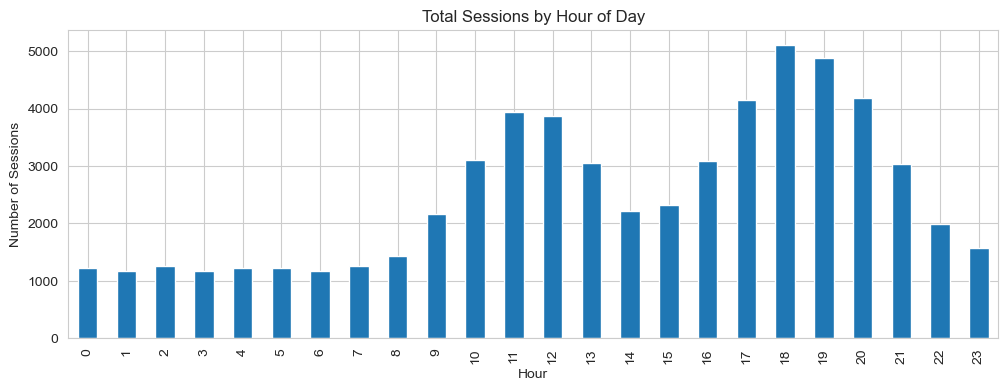

Peak hours (top 25%): [11, 12, 17, 18, 19, 20]


In [13]:
# Add time features
session_df['hour'] = session_df['timestamp'].dt.hour
session_df['day_of_week'] = session_df['timestamp'].dt.dayofweek

# Hourly demand pattern
hourly_sessions = session_df.groupby('hour').size()
plt.figure(figsize=(12, 4))
hourly_sessions.plot(kind='bar')
plt.title('Total Sessions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Sessions')
plt.show()

# Define peak hours (adjust threshold as needed)
threshold = hourly_sessions.quantile(0.75)
peak_hours = hourly_sessions[hourly_sessions > threshold].index.tolist()
print(f"Peak hours (top 25%): {peak_hours}")

#### Outcome Ordered and Blocked by Time of Day 

<Figure size 1200x600 with 0 Axes>

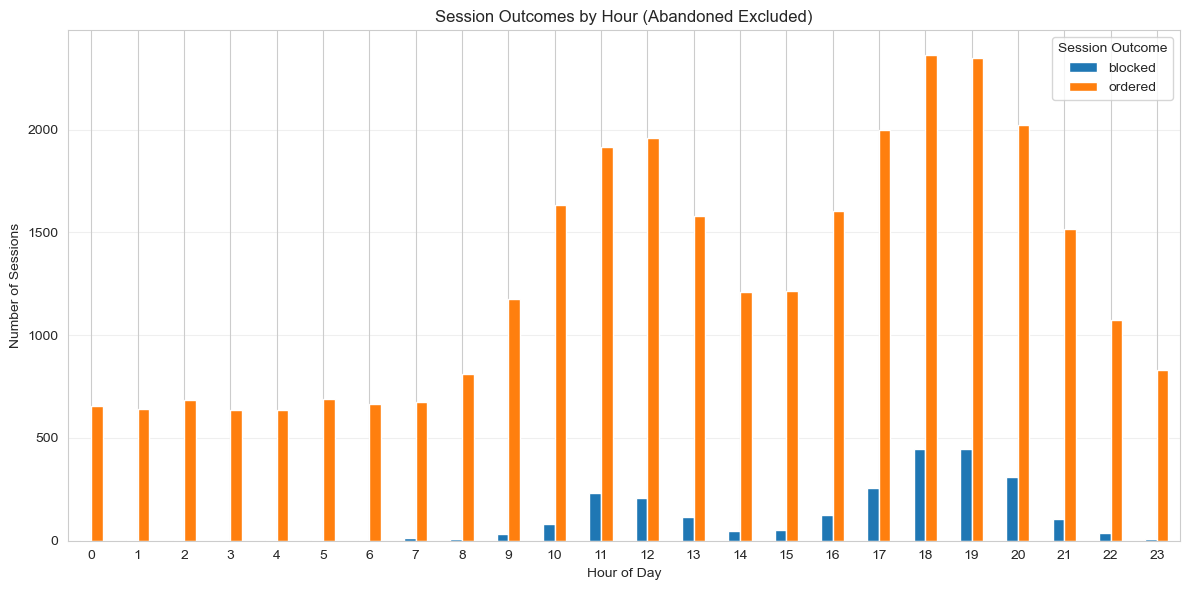


Session Outcomes by Hour:
session_outcome  blocked  ordered
hour                             
0                      5      654
1                      2      643
2                      4      687
3                      4      636
4                      4      635
5                      3      692
6                      4      667
7                     12      675
8                      6      809
9                     31     1175
10                    79     1634
11                   230     1918
12                   206     1962
13                   115     1579
14                    45     1210
15                    53     1214
16                   125     1603
17                   255     1999
18                   448     2365
19                   444     2347
20                   311     2023
21                   105     1519
22                    36     1076
23                     9      829


In [47]:
# Filter out 'abandoned' and plot by hour
session_no_abandoned = session_df[session_df['session_outcome'] != 'abandoned']

# Count by hour and outcome
outcome_by_hour = session_no_abandoned.groupby(['hour', 'session_outcome']).size().unstack(fill_value=0)

# Plot
plt.figure(figsize=(12, 6))
outcome_by_hour.plot(kind='bar', stacked=False)
plt.title('Session Outcomes by Hour (Abandoned Excluded)')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Sessions')
plt.legend(title='Session Outcome')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Show the data
print("\nSession Outcomes by Hour:")
print(outcome_by_hour)

#### Blocked Analysis by Hub

BLOCKED ORDERS ANALYSIS BY HUB

Outcomes by Hub:
session_outcome  abandoned  blocked  ordered  total  blocked_rate  \
nest_id                                                             
1                     2495      609     2416   5520      0.110326   
0                     2350      534     2344   5228      0.102142   
2                     2261      442     2325   5028      0.087908   
3                     2440      428     2301   5169      0.082801   
4                     1971      341     2005   4317      0.078990   
5                     2034       72     2647   4753      0.015148   
6                     2009       52     2448   4509      0.011532   
7                     1847       37     2271   4155      0.008905   
8                     1525       12     1977   3514      0.003415   
9                     1689        9     2114   3812      0.002361   
10                    1382        0     1823   3205      0.000000   
11                    1390        0     1636   3026   

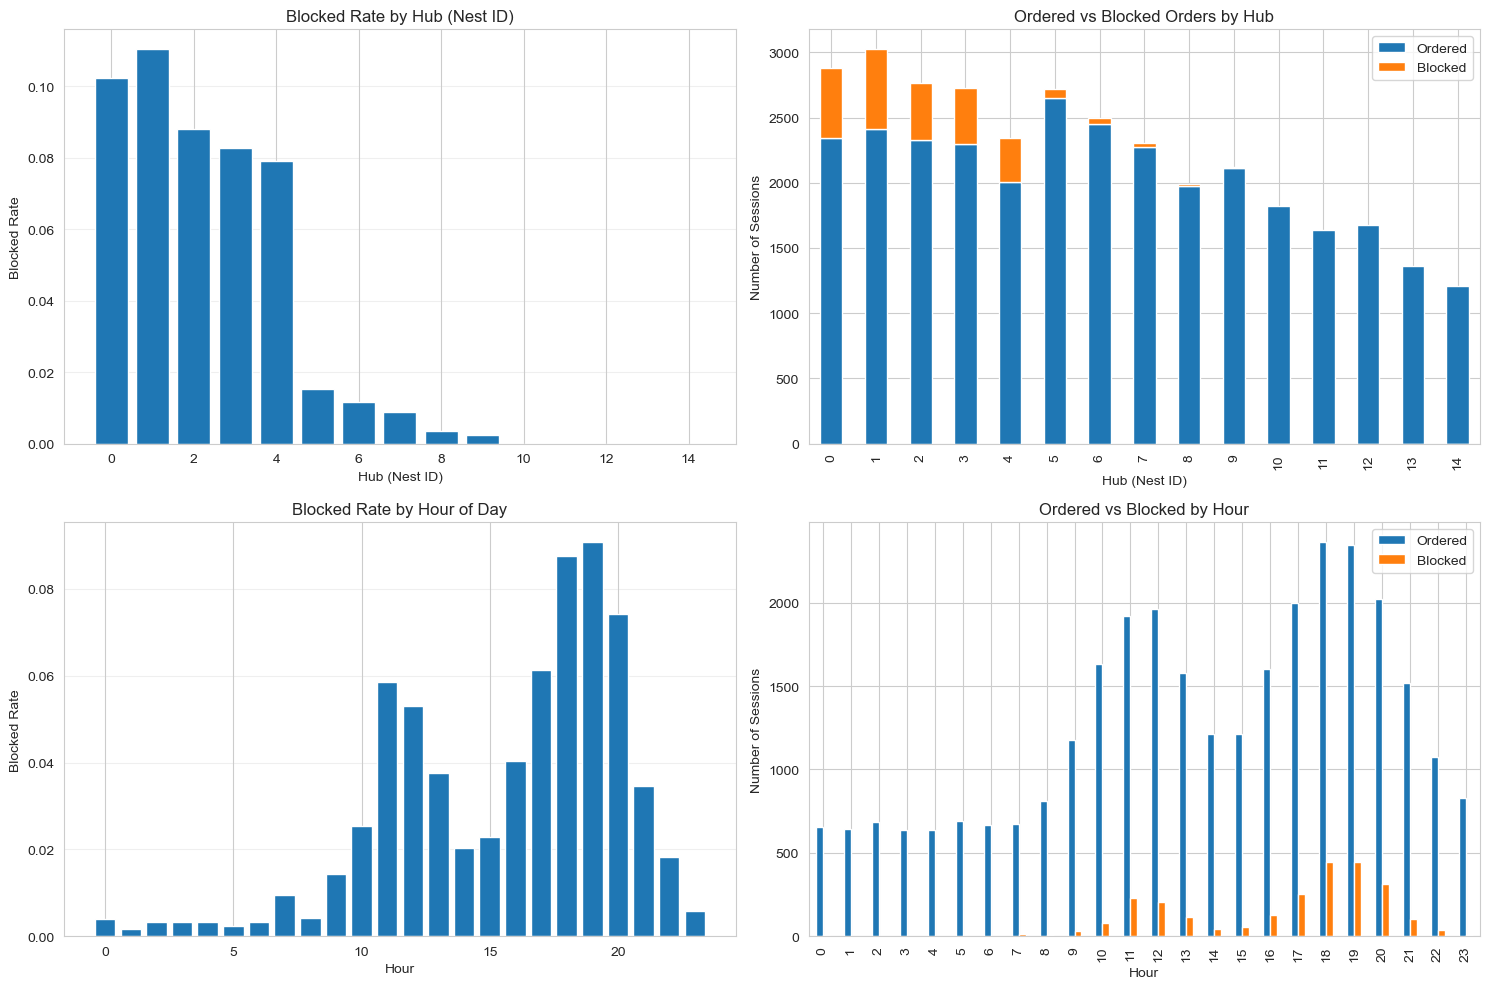


CAPACITY CORRELATION CHECK

Correlation between capacity used and blocked orders:
               capacity_used  blocked_count
capacity_used        1.00000        0.92679
blocked_count        0.92679        1.00000


In [48]:
# Analyze blocked orders by hub
print("BLOCKED ORDERS ANALYSIS BY HUB")
print("="*80)

# Count outcomes by hub
outcome_by_hub = session_df.groupby(['nest_id', 'session_outcome']).size().unstack(fill_value=0)
outcome_by_hub['total'] = outcome_by_hub.sum(axis=1)
outcome_by_hub['blocked_rate'] = outcome_by_hub['blocked'] / outcome_by_hub['total']
outcome_by_hub['ordered_rate'] = outcome_by_hub['ordered'] / outcome_by_hub['total']

print("\nOutcomes by Hub:")
print(outcome_by_hub.sort_values('blocked_rate', ascending=False))

# Check blocked orders by hour (capacity constraint indicator)
print("\n" + "="*80)
print("BLOCKED ORDERS BY HOUR (Potential Capacity Constraints)")
print("="*80)

blocked_by_hour = session_df[session_df['session_outcome']=='blocked'].groupby('hour').size()
ordered_by_hour = session_df[session_df['session_outcome']=='ordered'].groupby('hour').size()
total_by_hour = session_df.groupby('hour').size()

hour_analysis = pd.DataFrame({
    'blocked': blocked_by_hour,
    'ordered': ordered_by_hour,
    'total': total_by_hour
}).fillna(0)
hour_analysis['blocked_rate'] = hour_analysis['blocked'] / hour_analysis['total']

print(hour_analysis.sort_values('blocked_rate', ascending=False))

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Blocked rate by hub
axes[0, 0].bar(outcome_by_hub.index, outcome_by_hub['blocked_rate'])
axes[0, 0].set_title('Blocked Rate by Hub (Nest ID)')
axes[0, 0].set_xlabel('Hub (Nest ID)')
axes[0, 0].set_ylabel('Blocked Rate')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Ordered vs Blocked by hub
outcome_by_hub[['ordered', 'blocked']].plot(kind='bar', ax=axes[0, 1], stacked=True)
axes[0, 1].set_title('Ordered vs Blocked Orders by Hub')
axes[0, 1].set_xlabel('Hub (Nest ID)')
axes[0, 1].set_ylabel('Number of Sessions')
axes[0, 1].legend(['Ordered', 'Blocked'])

# Plot 3: Blocked rate by hour
axes[1, 0].bar(hour_analysis.index, hour_analysis['blocked_rate'])
axes[1, 0].set_title('Blocked Rate by Hour of Day')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Blocked Rate')
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Ordered vs Blocked by hour
hour_analysis[['ordered', 'blocked']].plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Ordered vs Blocked by Hour')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Number of Sessions')
axes[1, 1].legend(['Ordered', 'Blocked'])

plt.tight_layout()
plt.show()

# Check correlation between blocked and capacity demand
print("\n" + "="*80)
print("CAPACITY CORRELATION CHECK")
print("="*80)
capacity_by_hour = session_df[session_df['converted']==1].groupby('hour')['capacity_units'].sum()
correlation = pd.DataFrame({
    'capacity_used': capacity_by_hour,
    'blocked_count': blocked_by_hour
}).fillna(0).corr()

print("\nCorrelation between capacity used and blocked orders:")
print(correlation)

### Conversion analysis by price

In [14]:
# Conversion rate overall
conversion_rate = (session_df['session_outcome'] == 'ordered').mean()
print(f"Overall conversion rate: {conversion_rate:.2%}")

# Conversion by price point (for completed sessions)
ordered = session_df[session_df['session_outcome'] == 'ordered'].copy()
ordered['price_bin'] = pd.cut(ordered['delivery_fee'], bins=[0, 2, 3, 4, 5, 10])

conversion_by_price = ordered.groupby('price_bin').size()
print("\nOrders by price range:")
print(conversion_by_price)

Overall conversion rate: 51.02%

Orders by price range:
price_bin
(0, 2]     10792
(2, 3]      5420
(3, 4]      4761
(4, 5]      5114
(5, 10]     4464
dtype: int64


### Hub demand variability

In [15]:
# Sessions per hub
hub_volume = session_df.groupby('nest_id').size().sort_values(ascending=False)
print("Sessions by hub:")
print(hub_volume)

# Peak vs off-peak by hub (add peak_hour flag first)
session_df['is_peak'] = session_df['hour'].isin(peak_hours)
hub_peak_dist = session_df.groupby(['nest_id', 'is_peak']).size().unstack(fill_value=0)
hub_peak_dist['peak_ratio'] = hub_peak_dist[True] / (hub_peak_dist[True] + hub_peak_dist[False])
print("\nPeak hour concentration by hub:")
print(hub_peak_dist.sort_values('peak_ratio', ascending=False))

Sessions by hub:
nest_id
1     5520
0     5228
3     5169
2     5028
5     4753
6     4509
4     4317
7     4155
9     3812
8     3514
10    3205
11    3026
12    2943
13    2486
14    2215
dtype: int64

Peak hour concentration by hub:
is_peak  False  True  peak_ratio
nest_id                         
4         2393  1924    0.445680
3         2878  2291    0.443219
6         2514  1995    0.442448
1         3085  2435    0.441123
2         2814  2214    0.440334
13        1392  1094    0.440064
5         2667  2086    0.438881
7         2338  1817    0.437304
14        1252   963    0.434763
0         2972  2256    0.431523
10        1822  1383    0.431513
11        1721  1305    0.431262
12        1675  1268    0.430853
8         2008  1506    0.428571
9         2199  1613    0.423137


### Price elasticity signal

In [16]:
# Merge pricing schedule with sessions to compare shown vs. charged prices
# First, round session timestamps to match pricing intervals
session_df['date_hour'] = session_df['timestamp'].dt.floor('15min')  # assuming 15min intervals

# Merge to get the price shown
merged = session_df.merge(pricing_df, on=['nest_id', 'date_hour'], 
                         how='left', suffixes=('_charged', '_shown'))

# Conversion rate by price shown
price_bins = pd.cut(merged['delivery_fee_shown'], bins=5)
elasticity = merged.groupby(price_bins).agg({
    'session_outcome': lambda x: (x == 'ordered').mean()
}).round(3)
print("Conversion rate by price shown:")
print(elasticity)

Conversion rate by price shown:
                    session_outcome
delivery_fee_shown                 
(0.984, 2.19]                 0.539
(2.19, 3.39]                  0.516
(3.39, 4.59]                  0.505
(4.59, 5.79]                  0.504
(5.79, 6.99]                  0.468


### Pricing time intervals

In [17]:
pricing_df['date_hour_diff'] = pricing_df.groupby('nest_id')['date_hour'].diff()
print(pricing_df['date_hour_diff'].value_counts().head())

date_hour_diff
0 days 01:00:00    21480
Name: count, dtype: int64


### Pricing Patterns

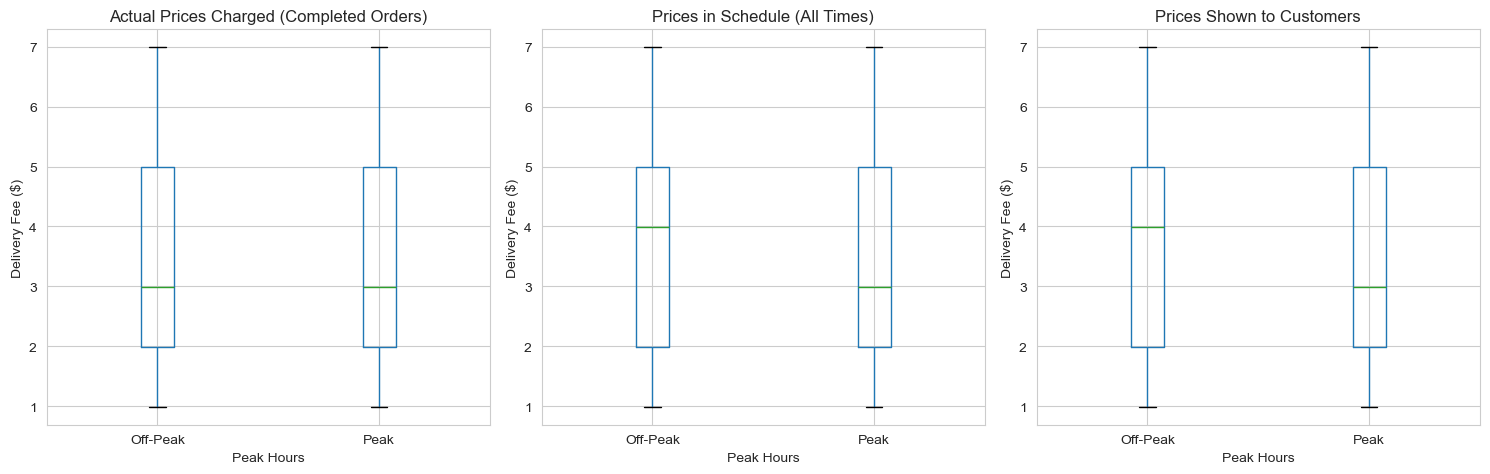

In [41]:
# Box plots for original pricing patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Session data - actual prices charged for orders
session_df[session_df['converted']==1].boxplot(column='delivery_fee', by='is_peak', ax=axes[0])
axes[0].set_title('Actual Prices Charged (Completed Orders)')
axes[0].set_xlabel('Peak Hours')
axes[0].set_ylabel('Delivery Fee ($)')
axes[0].set_xticklabels(['Off-Peak', 'Peak'])

# Plot 2: Pricing schedule - prices shown
pricing_df.boxplot(column='delivery_fee', by='is_peak', ax=axes[1])
axes[1].set_title('Prices in Schedule (All Times)')
axes[1].set_xlabel('Peak Hours')
axes[1].set_ylabel('Delivery Fee ($)')
axes[1].set_xticklabels(['Off-Peak', 'Peak'])

# Plot 3: Merged - prices shown to customers
merged.boxplot(column='delivery_fee_shown', by='is_peak', ax=axes[2])
axes[2].set_title('Prices Shown to Customers')
axes[2].set_xlabel('Peak Hours')
axes[2].set_ylabel('Delivery Fee ($)')
axes[2].set_xticklabels(['Off-Peak', 'Peak'])

plt.suptitle('')  # Remove default suptitle
plt.tight_layout()
plt.show()

## Feature Engineering + Model Setup

### Create key features

In [18]:
# Time-based features
session_df['hour'] = session_df['timestamp'].dt.hour
session_df['day_of_week'] = session_df['timestamp'].dt.dayofweek
session_df['is_weekend'] = session_df['day_of_week'].isin([5, 6]).astype(int)
session_df['is_peak'] = session_df['hour'].isin(peak_hours)  # use peak hours from Phase 3

# Categorical encoding for order_type
session_df['order_type_encoded'] = session_df['order_type'].astype('category').cat.codes

# Distance bins
session_df['distance_bin'] = pd.cut(session_df['distance_miles'], 
                                    bins=[0, 3, 6, 9, 100], 
                                    labels=['short', 'medium', 'long', 'very_long'])

In [19]:
print(session_df['day_of_week'].head())
print(session_df['day_of_week'].tail())

0    0
1    0
2    0
3    0
4    0
Name: day_of_week, dtype: int32
59875    5
59876    5
59877    5
59878    5
59879    5
Name: day_of_week, dtype: int32


In [20]:
print(session_df['is_weekend'].head())
print(session_df['is_weekend'].tail())

0    0
1    0
2    0
3    0
4    0
Name: is_weekend, dtype: int64
59875    1
59876    1
59877    1
59878    1
59879    1
Name: is_weekend, dtype: int64


In [21]:
session_df.head()
session_df.dtypes

timestamp             datetime64[ns]
user_id                        int64
nest_id                        int64
order_type                    object
distance_miles               float64
delivery_fee                 float64
subtotal                     float64
session_outcome               object
hour                           int32
day_of_week                    int32
is_peak                         bool
date_hour             datetime64[ns]
is_weekend                     int64
order_type_encoded              int8
distance_bin                category
dtype: object

### Target variable

In [22]:
# Binary conversion target
session_df['converted'] = (session_df['session_outcome'] == 'ordered').astype(int)

### Hub-level aggregations

In [23]:
# Hub demand intensity (for later use)
hub_features = session_df.groupby('nest_id').agg({
    'converted': 'mean',  # conversion rate
    'user_id': 'count',   # total volume
    'is_peak': 'mean'     # peak concentration
}).rename(columns={'user_id': 'total_sessions', 'is_peak': 'peak_concentration'})

print("Hub-level features:")
print(hub_features)

Hub-level features:
         converted  total_sessions  peak_concentration
nest_id                                               
0         0.448355            5228            0.431523
1         0.437681            5520            0.441123
2         0.462411            5028            0.440334
3         0.445154            5169            0.443219
4         0.464443            4317            0.445680
5         0.556911            4753            0.438881
6         0.542914            4509            0.442448
7         0.546570            4155            0.437304
8         0.562607            3514            0.428571
9         0.554565            3812            0.423137
10        0.568799            3205            0.431513
11        0.540648            3026            0.431262
12        0.569487            2943            0.430853
13        0.547466            2486            0.440064
14        0.544921            2215            0.434763


### Calculate Capacity Metrics

In [24]:
# Aircraft turnaround time calculation
def calculate_delivery_time(distance_miles):
    """
    Total time per delivery in minutes:
    - 2 min loading
    - 1 min undock/transition
    - Flight time (round trip at 70 mph)
    - 1 min transition to dock
    - 1 min delivery
    """
    flight_time_minutes = (distance_miles * 2) / 70 * 60  # round trip
    total_time = 2 + 1 + flight_time_minutes + 1 + 1
    return total_time

session_df['delivery_time_min'] = session_df['distance_miles'].apply(calculate_delivery_time)

# Hourly capacity demand
session_df['capacity_units'] = session_df['delivery_time_min'] / 60  # normalize to hours

hourly_demand = session_df[session_df['converted'] == 1].groupby('hour').agg({
    'capacity_units': 'sum',  # total capacity needed
    'converted': 'count'       # number of orders
})

### Customer Experience Features

In [25]:
# Identify repeat customers and their price sensitivity
user_behavior = session_df.groupby('user_id').agg({
    'converted': ['sum', 'count', 'mean'],  # orders, sessions, conversion rate
    'delivery_fee': 'mean',                 # avg price paid
    'timestamp': ['min', 'max']             # first and last session
}).reset_index()

user_behavior.columns = ['user_id', 'total_orders', 'total_sessions', 
                         'conversion_rate', 'avg_price_paid', 'first_session', 'last_session']

# Calculate customer lifetime (days active)
user_behavior['days_active'] = (user_behavior['last_session'] - user_behavior['first_session']).dt.days

# Flag valuable customers (multiple orders)
user_behavior['is_repeat_customer'] = (user_behavior['total_orders'] >= 2).astype(int)

# Merge back to sessions
session_df = session_df.merge(user_behavior[['user_id', 'is_repeat_customer', 'conversion_rate']], 
                              on='user_id', how='left', suffixes=('', '_user'))

### Demand Intensity Score

In [26]:
# Calculate demand intensity per hub-hour
demand_intensity = session_df.groupby(['nest_id', 'hour']).agg({
    'user_id': 'count',  # total sessions
    'converted': 'sum'    # total orders
}).rename(columns={'user_id': 'sessions', 'converted': 'orders'})

demand_intensity['demand_score'] = demand_intensity['orders'] / demand_intensity['sessions']
demand_intensity = demand_intensity.reset_index()

# Merge back
session_df = session_df.merge(demand_intensity[['nest_id', 'hour', 'demand_score']], 
                              on=['nest_id', 'hour'], how='left')

In [27]:
session_df.describe()

,timestamp,user_id,nest_id,distance_miles,delivery_fee,subtotal,hour,day_of_week,date_hour,is_weekend,order_type_encoded,converted,delivery_time_min,capacity_units,is_repeat_customer,conversion_rate,demand_score
count,59880,59880.000000,59880.000000,59880.000000,30551.000000,30551.000000,59880.000000,59880.000000,59880,59880.000000,59880.000000,59880.000000,59880.000000,59880.000000,59880.000000,59880.000000,59880.000000
mean,2024-01-07 01:49:15.105210368,2509.278758,5.922762,7.006936,3.532961,27.011318,13.758868,2.857599,2024-01-07 01:42:15.225450752,0.209886,0.799733,0.510204,17.011889,0.283531,0.956029,0.510204,0.510204
min,2024-01-01 08:01:00,0.000000,0.000000,2.000000,0.990000,1.860000,0.000000,0.000000,2024-01-01 08:00:00,0.000000,0.000000,0.000000,8.428571,0.140476,0.000000,0.000000,0.314583
25%,2024-01-04 11:37:45,1262.000000,2.000000,4.500000,1.990000,20.530000,10.000000,1.000000,2024-01-04 11:30:00,0.000000,0.000000,0.000000,12.714286,0.211905,1.000000,0.375000,0.469388
50%,2024-01-06 17:40:00,2512.000000,5.000000,7.000000,2.990000,26.880000,15.000000,3.000000,2024-01-06 17:30:00,0.000000,1.000000,1.000000,17.000000,0.283333,1.000000,0.500000,0.525490
75%,2024-01-09 18:59:00,3759.000000,9.000000,9.500000,4.990000,33.340000,19.000000,4.000000,2024-01-09 18:45:00,0.000000,1.000000,1.000000,21.285714,0.354762,1.000000,0.647059,0.561404
max,2024-01-13 11:01:00,4999.000000,14.000000,12.000000,6.990000,66.300000,23.000000,6.000000,2024-01-13 11:00:00,1.000000,2.000000,1.000000,25.571429,0.426190,1.000000,1.000000,0.694915
std,NaN,1442.364123,4.134974,2.888336,1.938678,9.453580,5.974555,1.868802,NaN,0.407231,0.599220,0.499900,4.951433,0.082524,0.205033,0.187494,0.074794


In [28]:
merged.describe()

,timestamp,user_id,nest_id,distance_miles,delivery_fee_charged,subtotal,hour,day_of_week,date_hour,delivery_fee_shown
count,59880,59880.000000,59880.000000,59880.000000,30551.000000,30551.000000,59880.000000,59880.000000,59880,14804.000000
mean,2024-01-07 01:49:15.105210368,2509.278758,5.922762,7.006936,3.532961,27.011318,13.758868,2.857599,2024-01-07 01:42:15.225450752,3.614831
min,2024-01-01 08:01:00,0.000000,0.000000,2.000000,0.990000,1.860000,0.000000,0.000000,2024-01-01 08:00:00,0.990000
25%,2024-01-04 11:37:45,1262.000000,2.000000,4.500000,1.990000,20.530000,10.000000,1.000000,2024-01-04 11:30:00,1.990000
50%,2024-01-06 17:40:00,2512.000000,5.000000,7.000000,2.990000,26.880000,15.000000,3.000000,2024-01-06 17:30:00,2.990000
75%,2024-01-09 18:59:00,3759.000000,9.000000,9.500000,4.990000,33.340000,19.000000,4.000000,2024-01-09 18:45:00,4.990000
max,2024-01-13 11:01:00,4999.000000,14.000000,12.000000,6.990000,66.300000,23.000000,6.000000,2024-01-13 11:00:00,6.990000
std,NaN,1442.364123,4.134974,2.888336,1.938678,9.453580,5.974555,1.868802,NaN,1.948369


## Modeling Approach

### Price Elasticity Model (Logistic Regression)

In [29]:
session_df.dtypes

timestamp             datetime64[ns]
user_id                        int64
nest_id                        int64
order_type                    object
distance_miles               float64
delivery_fee                 float64
subtotal                     float64
session_outcome               object
hour                           int32
day_of_week                    int32
is_peak                         bool
date_hour             datetime64[ns]
is_weekend                     int64
order_type_encoded              int8
distance_bin                category
converted                      int64
delivery_time_min            float64
capacity_units               float64
is_repeat_customer             int64
conversion_rate              float64
demand_score                 float64
dtype: object

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Prepare features for conversion prediction
features = ['delivery_fee_shown', 'distance_miles', 'hour', 'day_of_week', 
            'is_weekend', 'order_type_encoded', 'demand_score']

# Create merged dataframe with pricing data
merged = session_df.merge(pricing_df, on=['nest_id', 'date_hour'], 
                         how='left', suffixes=('_charged', '_shown'))

# Filter to sessions where we have price shown
model_df = merged[merged['delivery_fee_shown'].notna()].copy()
X = model_df[features]
y = model_df['converted']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit model
elasticity_model = LogisticRegression(random_state=42)
elasticity_model.fit(X_train_scaled, y_train)

# Evaluate
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
y_pred = elasticity_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, elasticity_model.predict_proba(X_test_scaled)[:, 1]):.3f}")
print("\nFeature Coefficients:")
for feat, coef in zip(features, elasticity_model.coef_[0]):
    print(f"  {feat}: {coef:.4f}")

Accuracy: 0.587
ROC-AUC: 0.635

Feature Coefficients:
  delivery_fee_shown: -0.0974
  distance_miles: 0.0059
  hour: -0.0246
  day_of_week: -0.1066
  is_weekend: 0.0933
  order_type_encoded: 0.4903
  demand_score: 0.2821


In [31]:
#Data quality check

merged.head()

,timestamp,user_id,nest_id,order_type,distance_miles,delivery_fee_charged,subtotal,session_outcome,hour,day_of_week,is_peak,date_hour,is_weekend,order_type_encoded,distance_bin,converted,delivery_time_min,capacity_units,is_repeat_customer,conversion_rate,demand_score,delivery_fee_shown,date_hour_diff
0,2024-01-01 08:01:00,1746,9,Meal,7.3,2.99,44.36,ordered,8,0,False,2024-01-01 08:00:00,0,1,long,1,17.514286,0.291905,1,0.800000,0.537634,2.99,NaT
1,2024-01-01 08:01:00,3208,8,Grocery,4.4,NaN,NaN,abandoned,8,0,False,2024-01-01 08:00:00,0,0,medium,0,12.542857,0.209048,1,0.461538,0.488889,6.99,NaT
2,2024-01-01 08:04:00,3054,4,Meal,8.7,NaN,NaN,abandoned,8,0,False,2024-01-01 08:00:00,0,1,long,0,19.914286,0.331905,1,0.454545,0.574074,3.99,NaT
3,2024-01-01 08:05:00,806,1,Meal,11.8,NaN,NaN,abandoned,8,0,False,2024-01-01 08:00:00,0,1,very_long,0,25.228571,0.420476,1,0.555556,0.531250,4.99,NaT
4,2024-01-01 08:05:00,1731,11,Meal,6.1,0.99,29.12,ordered,8,0,False,2024-01-01 08:00:00,0,1,long,1,15.457143,0.257619,1,0.454545,0.491803,0.99,NaT


### Insights from Model

**Model Performance:**

Accuracy: 58.7% - Modest, but reasonable given you're predicting human behavior
ROC-AUC: 0.635 - Better than random (0.5), shows the model has some predictive power but there's room for improvement

**Feature Coefficients (what drives conversion):**  
Price Sensitivity:
* delivery_fee_shown: -0.097 - Higher prices reduce conversion (as expected). This is your price elasticity - for each $1 increase, conversion probability drops

Strongest Positive Drivers:
* order_type_encoded: 0.490 - Biggest impact! Order type matters a lot (likely Pharma > Grocery > Meal in urgency/willingness to pay)
* demand_score: 0.282 - Higher demand periods = higher conversion (people more committed when others are ordering too)

Time Factors:
* day_of_week: -0.107 - Later in week = lower conversion (Monday rush > Sunday lazy?)
* hour: -0.025 - Slight decrease as day progresses
* is_weekend: 0.093 - Weekends boost conversion slightly

Distance:
* distance_miles: 0.006 - Negligible impact (surprising! Distance doesn't deter customers much)

**Key Takeaway:**  
Customers care more about what they're ordering (pharma urgency) and when (demand periods) than price or distance. This means you have pricing power, especially for urgent categories.

### Conversion by order type

In [32]:
# Order type conversion rates
print("CONVERSION BY ORDER TYPE")
print("=" * 60)
order_conversion = session_df.groupby('order_type').agg({
    'converted': ['sum', 'count', 'mean']
}).round(3)
order_conversion.columns = ['orders', 'sessions', 'conversion_rate']
print(order_conversion.sort_values('conversion_rate', ascending=False))

# Average price paid by order type
print("\n\nAVERAGE DELIVERY FEE BY ORDER TYPE")
print("=" * 60)
price_by_type = session_df[session_df['converted']==1].groupby('order_type')['delivery_fee'].agg(['mean', 'median', 'min', 'max']).round(2)
print(price_by_type)

# Order type by time of day
print("\n\nORDER TYPE DISTRIBUTION BY HOUR")
print("=" * 60)
type_by_hour = session_df.groupby(['hour', 'order_type'])['converted'].sum().unstack(fill_value=0)
print(type_by_hour)

CONVERSION BY ORDER TYPE
            orders  sessions  conversion_rate
order_type                                   
Pharma        5059      5955            0.850
Meal         18583     35978            0.517
Grocery       6909     17947            0.385


AVERAGE DELIVERY FEE BY ORDER TYPE
            mean  median   min   max
order_type                          
Grocery     3.46    2.99  0.99  6.99
Meal        3.53    2.99  0.99  6.99
Pharma      3.65    3.99  0.99  6.99


ORDER TYPE DISTRIBUTION BY HOUR
order_type  Grocery  Meal  Pharma
hour                             
0               142   403     109
1               134   402     107
2               147   418     122
3               153   370     113
4               155   374     106
5               149   446      97
6               156   394     117
7               163   379     133
8               185   481     143
9               296   667     212
10              361  1008     265
11              423  1152     343
12           

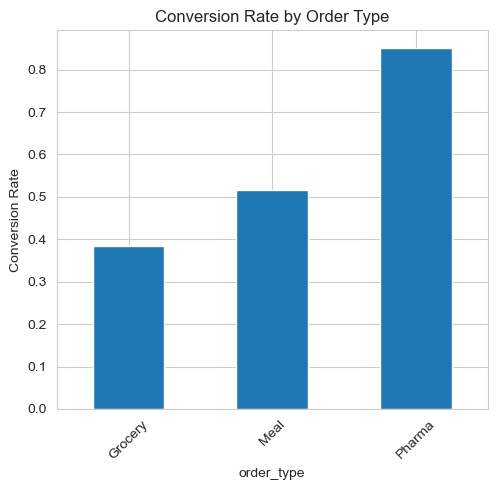

In [33]:
# Visualize
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
order_conversion['conversion_rate'].plot(kind='bar')
plt.title('Conversion Rate by Order Type')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

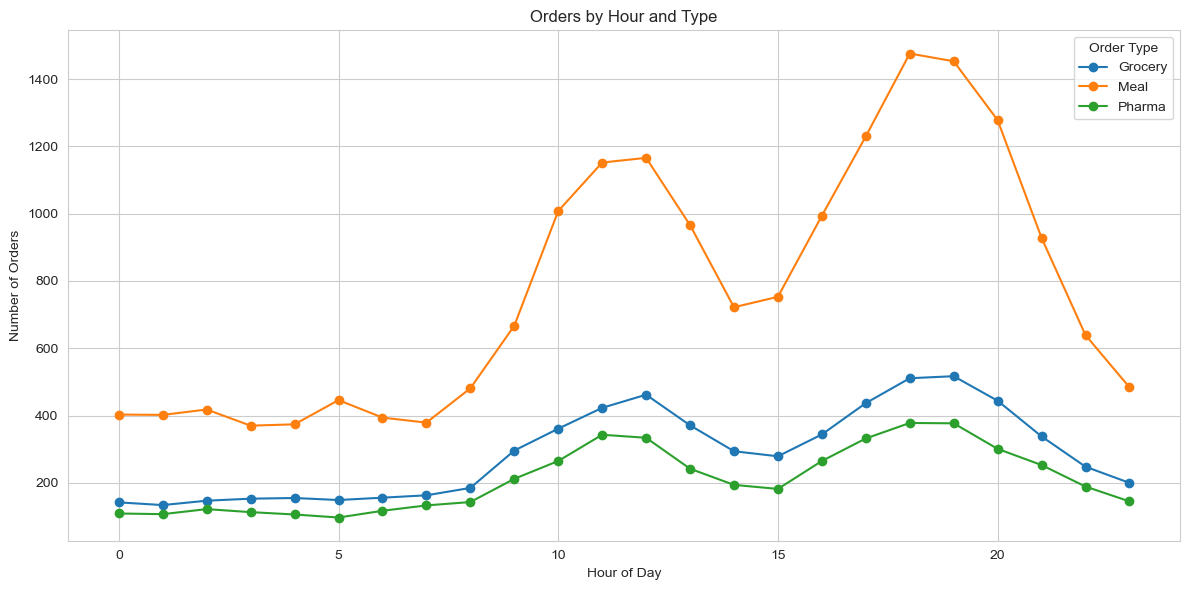

In [34]:
# Visualize
plt.figure(figsize=(10, 5))

type_by_hour.plot(kind='line', marker='o')
plt.title('Orders by Hour and Type')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.legend(title='Order Type')

plt.tight_layout()
plt.show()

<Figure size 1400x500 with 0 Axes>

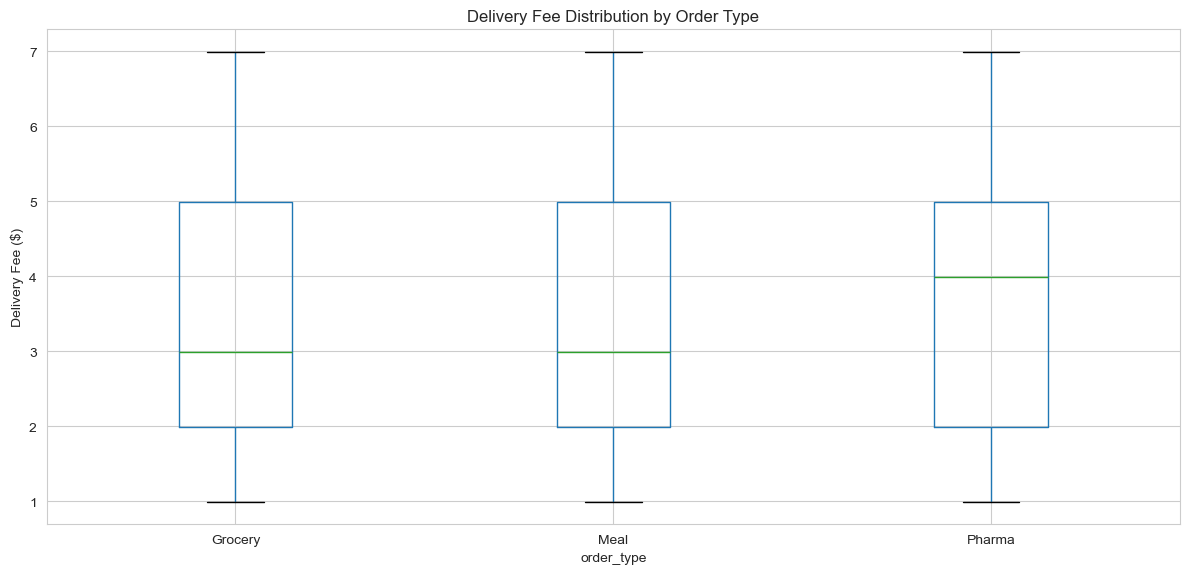

In [35]:
# Visualize
plt.figure(figsize=(14, 5))

session_df[session_df['converted']==1].boxplot(column='delivery_fee', by='order_type')
plt.title('Delivery Fee Distribution by Order Type')
plt.suptitle('')
plt.ylabel('Delivery Fee ($)')

plt.tight_layout()
plt.show()

In [36]:
# Price sensitivity by order type
print("\n\nPRICE SENSITIVITY BY ORDER TYPE")
print("=" * 60)
for order_type in session_df['order_type'].unique():
    type_data = merged[merged['order_type'] == order_type].copy()
    type_data['price_bin'] = pd.cut(type_data['delivery_fee_shown'], bins=[0, 2, 3, 4, 10])
    price_sens = type_data.groupby('price_bin')['converted'].mean()
    print(f"\n{order_type}:")
    print(price_sens.round(3))



PRICE SENSITIVITY BY ORDER TYPE

Meal:
price_bin
(0, 2]     0.547
(2, 3]     0.527
(3, 4]     0.508
(4, 10]    0.489
Name: converted, dtype: float64

Grocery:
price_bin
(0, 2]     0.430
(2, 3]     0.387
(3, 4]     0.400
(4, 10]    0.365
Name: converted, dtype: float64

Pharma:
price_bin
(0, 2]     0.845
(2, 3]     0.861
(3, 4]     0.813
(4, 10]    0.861
Name: converted, dtype: float64


## Define Pricing Strategy & Simulate

### Pricing Strategy 1

In [42]:
# Price sensitivity by customer segment
def calculate_dynamic_price(row, base_price=2.99):
    """
    Dynamic pricing logic based on:
    - Demand intensity (surge pricing)
    - Customer value (loyalty discount)
    - Distance (cost-based adjustment)
    """
    price = base_price
    
    # Demand-based multiplier (surge pricing during high demand)
    if row['demand_score'] > 0.7:  # High conversion periods
        price *= 1.3  # 30% surge
    elif row['demand_score'] > 0.5:
        price *= 1.15  # 15% surge
    elif row['demand_score'] < 0.3:  # Low demand - stimulate orders
        price *= 0.85  # 15% discount
    
    # Distance adjustment (longer = higher)
    if row['distance_miles'] > 8:
        price += 1.0
    elif row['distance_miles'] > 5:
        price += 0.5
    
    # Customer loyalty protection (priority #1)
    if row['is_repeat_customer'] == 1 and row['demand_score'] > 0.7:
        price *= 0.95  # 5% loyalty discount during surge
    
    # Floor and ceiling
    price = max(0.99, min(price, 5.99))
    
    return round(price, 2)

# Test on sample data
sample = merged[merged['delivery_fee_shown'].notna()].sample(1000, random_state=42).copy()
sample['proposed_price'] = sample.apply(calculate_dynamic_price, axis=1)

#### Simulate Revenue & Conversion Impact - 1

In [38]:
# Predict conversion at proposed prices
def simulate_outcome(row, model, scaler, features):
    """Predict conversion probability with new price"""
    test_features = row[features].copy()
    test_features['delivery_fee_shown'] = row['proposed_price']
    
    scaled = scaler.transform([test_features])
    prob = model.predict_proba(scaled)[0, 1]
    return prob

sample['predicted_conversion'] = sample.apply(
    lambda row: simulate_outcome(row, elasticity_model, scaler, features), axis=1
)

# Revenue comparison
sample['current_revenue'] = sample['delivery_fee_shown'] * sample['converted']
sample['predicted_revenue'] = sample['proposed_price'] * sample['predicted_conversion']

print("SIMULATION RESULTS")
print("=" * 60)
print(f"Current avg conversion: {sample['converted'].mean():.3f}")
print(f"Predicted avg conversion: {sample['predicted_conversion'].mean():.3f}")
print(f"Current avg revenue per session: ${sample['current_revenue'].mean():.2f}")
print(f"Predicted avg revenue per session: ${sample['predicted_revenue'].mean():.2f}")
print(f"Revenue lift: {(sample['predicted_revenue'].mean() / sample['current_revenue'].mean() - 1) * 100:.1f}%")

SIMULATION RESULTS
Current avg conversion: 0.512
Predicted avg conversion: 0.510
Current avg revenue per session: $1.87
Predicted avg revenue per session: $1.96
Revenue lift: 4.7%


#### Analyze price change results

In [39]:
# See how much prices actually changed
print("PRICE CHANGE ANALYSIS")
print("=" * 60)
print(f"Current avg price shown: ${sample['delivery_fee_shown'].mean():.2f}")
print(f"Proposed avg price: ${sample['proposed_price'].mean():.2f}")
print(f"Price change: {((sample['proposed_price'].mean() / sample['delivery_fee_shown'].mean()) - 1) * 100:.1f}%")

print("\nPrice changes by demand period:")
print(sample.groupby('is_peak').agg({
    'delivery_fee_shown': 'mean',
    'proposed_price': 'mean'
}).round(2))

PRICE CHANGE ANALYSIS
Current avg price shown: $3.70
Proposed avg price: $3.83
Price change: 3.5%

Price changes by demand period:
         delivery_fee_shown  proposed_price
is_peak                                    
False                  3.76            3.87
True                   3.61            3.77


### Pricing Strategy 2 - Multi-Pbjective Optimization with Constaints

#### Define Objective Functions & Constraints

In [43]:
# CONSTRAINT: Customer Experience Protection
# - Cap max price increase to avoid sticker shock
# - Maintain conversion for repeat customers
# - Set absolute price ceiling

# OBJECTIVE 1: Maximize Profit
def calculate_profit(price, conversion_prob, cost_per_delivery=1.50):
    """
    Profit = (Price - Cost) * Conversion_Probability
    Assumes $1.50 cost per delivery (fuel, maintenance, labor)
    """
    return (price - cost_per_delivery) * conversion_prob

# OBJECTIVE 2: Maximize Asset Utilization
# Minimize variance in hourly demand (smooth the curve)
def utilization_score(hourly_orders):
    """
    Lower variance = better utilization
    Target: flatten peak/off-peak difference
    """
    return -np.std(hourly_orders)  # negative because we minimize std

#### Grid Search for Optimal Price Multipliers

In [44]:
# Test different pricing strategies
import itertools

# Define parameter ranges to test
peak_multipliers = [1.2, 1.3, 1.4, 1.5, 1.6, 1.7]  # Peak surge %
offpeak_multipliers = [0.7, 0.75, 0.8, 0.85, 0.9]  # Off-peak discount %
loyalty_discounts = [0.85, 0.90, 0.95, 1.0]  # Repeat customer discount

results = []

for peak_mult, offpeak_mult, loyalty_disc in itertools.product(
    peak_multipliers, offpeak_multipliers, loyalty_discounts
):
    # Create pricing strategy
    def test_pricing(row, base=2.99):
        price = base
        
        if row['is_peak']:
            price *= peak_mult
        else:
            price *= offpeak_mult
        
        # Distance adjustment
        if row['distance_miles'] > 8:
            price += 1.5
        elif row['distance_miles'] > 5:
            price += 0.75
        
        # Loyalty
        if row['is_repeat_customer'] == 1 and row['is_peak']:
            price *= loyalty_disc
        
        price = max(0.99, min(price, 6.99))
        return round(price, 2)
    
    # Apply to sample
    test_sample = merged[merged['delivery_fee_shown'].notna()].sample(5000, random_state=42).copy()
    test_sample['test_price'] = test_sample.apply(test_pricing, axis=1)
    
    # Predict conversions
    X_test = test_sample[features].copy()
    X_test['delivery_fee_shown'] = test_sample['test_price']
    X_test_scaled = scaler.transform(X_test)
    test_sample['pred_conversion'] = elasticity_model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    total_profit = (test_sample['test_price'] - 1.50) * test_sample['pred_conversion']
    avg_profit = total_profit.mean()
    
    # Asset utilization: hourly order variance
    hourly_orders = test_sample.groupby('hour')['pred_conversion'].sum()
    utilization = -hourly_orders.std()  # Lower std = better
    
    # Customer experience: repeat customer conversion
    repeat_conversion = test_sample[test_sample['is_repeat_customer']==1]['pred_conversion'].mean()
    
    # Peak to off-peak shift
    peak_orders = test_sample[test_sample['is_peak']==True]['pred_conversion'].sum()
    offpeak_orders = test_sample[test_sample['is_peak']==False]['pred_conversion'].sum()
    demand_ratio = peak_orders / offpeak_orders
    
    results.append({
        'peak_mult': peak_mult,
        'offpeak_mult': offpeak_mult,
        'loyalty_disc': loyalty_disc,
        'avg_profit': avg_profit,
        'utilization_score': utilization,
        'repeat_conversion': repeat_conversion,
        'demand_ratio': demand_ratio,
        'total_orders': test_sample['pred_conversion'].sum()
    })

results_df = pd.DataFrame(results)

#### Apply Constraints & Find Pareto Optimal Solutions

In [45]:
# Apply customer experience constraints
# Constraint: Maintain repeat customer conversion above baseline
baseline_repeat_conversion = session_df[
    (session_df['is_repeat_customer']==1) & 
    (session_df['converted']==1)
].shape[0] / session_df[session_df['is_repeat_customer']==1].shape[0]

print(f"Baseline repeat customer conversion: {baseline_repeat_conversion:.3f}")

# Filter to strategies that protect CX
feasible = results_df[results_df['repeat_conversion'] >= baseline_repeat_conversion * 0.95]  # Allow 5% drop max

print(f"\nStrategies tested: {len(results_df)}")
print(f"Feasible strategies (CX protected): {len(feasible)}")

# Find best strategies
print("\n" + "="*80)
print("TOP 5 STRATEGIES BY PROFIT")
print("="*80)
top_profit = feasible.nlargest(5, 'avg_profit')
print(top_profit[['peak_mult', 'offpeak_mult', 'loyalty_disc', 'avg_profit', 
                  'utilization_score', 'demand_ratio']].to_string(index=False))

print("\n" + "="*80)
print("TOP 5 STRATEGIES BY UTILIZATION")
print("="*80)
top_util = feasible.nlargest(5, 'utilization_score')
print(top_util[['peak_mult', 'offpeak_mult', 'loyalty_disc', 'avg_profit', 
                'utilization_score', 'demand_ratio']].to_string(index=False))

# Find balanced solution (weighted score)
feasible['combined_score'] = (
    0.7 * (feasible['avg_profit'] / feasible['avg_profit'].max()) +  # 70% weight on profit
    0.3 * (feasible['utilization_score'] / feasible['utilization_score'].max())  # 30% on utilization
)

print("\n" + "="*80)
print("TOP 5 BALANCED STRATEGIES (70% Profit, 30% Utilization)")
print("="*80)
top_balanced = feasible.nlargest(5, 'combined_score')
print(top_balanced[['peak_mult', 'offpeak_mult', 'loyalty_disc', 'avg_profit', 
                    'utilization_score', 'demand_ratio', 'combined_score']].to_string(index=False))

Baseline repeat customer conversion: 0.529

Strategies tested: 120
Feasible strategies (CX protected): 120

TOP 5 STRATEGIES BY PROFIT
 peak_mult  offpeak_mult  loyalty_disc  avg_profit  utilization_score  demand_ratio
       1.7          0.90          1.00    1.475813         -47.711478      0.653409
       1.7          0.85          1.00    1.432046         -47.689254      0.651277
       1.7          0.90          0.95    1.425898         -48.104360      0.657937
       1.6          0.90          1.00    1.422245         -48.135353      0.658282
       1.7          0.80          1.00    1.387980         -47.667629      0.649161

TOP 5 STRATEGIES BY UTILIZATION
 peak_mult  offpeak_mult  loyalty_disc  avg_profit  utilization_score  demand_ratio
       1.7          0.70           1.0    1.298950         -47.626178      0.644972
       1.7          0.75           1.0    1.343614         -47.646603      0.647059
       1.7          0.80           1.0    1.387980         -47.667629      0

#### Visualize Trade-offs

In [46]:
# Extract best parameters
best = top_balanced.iloc[0]

print("\n" + "="*80)
print("RECOMMENDED PRICING STRATEGY")
print("="*80)
print(f"Peak hour multiplier: {best['peak_mult']:.2f}x")
print(f"Off-peak multiplier: {best['offpeak_mult']:.2f}x")
print(f"Loyalty discount: {best['loyalty_disc']:.2f}x")
print(f"\nExpected Results:")
print(f"  Average profit per session: ${best['avg_profit']:.2f}")
print(f"  Utilization improvement: {best['utilization_score']:.2f}")
print(f"  Repeat customer conversion: {best['repeat_conversion']:.1%}")
print(f"  Peak/off-peak ratio: {best['demand_ratio']:.2f}")

# Calculate improvement vs baseline
baseline_profit = (merged['delivery_fee_shown'] - 1.50).mean()
profit_improvement = (best['avg_profit'] / baseline_profit - 1) * 100

print(f"\n  Profit improvement vs baseline: {profit_improvement:.1f}%")


RECOMMENDED PRICING STRATEGY
Peak hour multiplier: 1.70x
Off-peak multiplier: 0.90x
Loyalty discount: 1.00x

Expected Results:
  Average profit per session: $1.48
  Utilization improvement: -47.71
  Repeat customer conversion: 50.5%
  Peak/off-peak ratio: 0.65

  Profit improvement vs baseline: -30.2%


## NEXT

1. Test new pricing logic
2. Step back and ask what approaches might be better.

## Questions to answer

**QUESTIONS**

Do delivery fee values in *pricing* match delivery fee values paid in *session*, for matching times?



## NOTES

### Considerations for model

**Conversion Rate**  
* Does conversion rate vary by time of day?
* Are peak times more or less reliable?
* How much variation is there in conversion rate at peak times? (Want to avoid situation where orders can't be met)

**Model Approach**  
(from research)  
Because vehicle supply is fixed:  
* Do not use a single log-log regression
* Do model latent demand vs fulfilled orders
* Do correct for price endogeneity
* Do allow elasticity to vary by time, hub, and congestion  
* Best balance: hierarchical censored models + GAMs, validated against ML demand models

### Exploratory

* Repeat user stats. How many? Max repeat, etc
* Day of week (and how many days?)
* Order type